# NLP Text Analysis Notebook


This notebook performs basic Natural Language Processing on text files: it cleans and tokenizes the text, expands contractions, computes paragraph/sentence/word statistics, and analyzes word frequency distributions. It also visualizes Zipf’s Law by plotting word rank versus frequency to show how a few words occur very often while most words are rare.

In [ ]:
## Libraries 
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt', quiet=True)

True

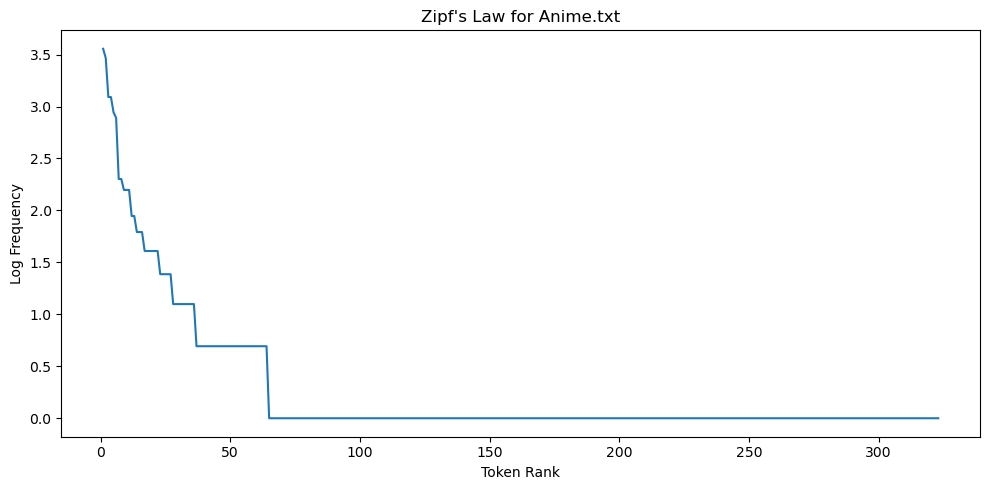

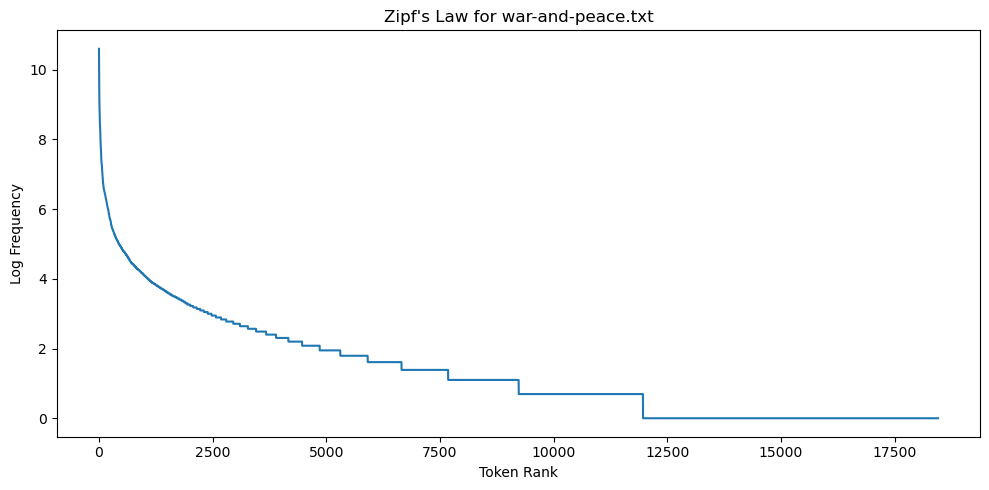

In [3]:
def read_text(path):
    with open(path, 'r', encoding='utf-8') as f:
        return f.read()

def get_paragraphs(text):
    paras = re.split(r'\n\s*\n', text)
    return [p for p in paras if p.strip()]

def expand_and_tokenize(text):
    CONTRACTIONS = {
        "n't": "not", "'ll": "will", "'ve": "have", "'d": "would", "'re": "are",
        "won't": ["will", "not"], "can't": ["can", "not"], "shan't": ["shall", "not"],
        "let's": ["let", "us"], "i'm": ["i", "am"]
    }
    PRONOUN_IS = {'he\'s', 'she\'s', 'it\'s', 'that\'s', 'here\'s', 'there\'s',
                  'what\'s', 'when\'s', 'where\'s', 'which\'s', 'who\'s', 'how\'s'}
    raw_tokens = word_tokenize(text)
    def split_multi_contraction(t):
        ptn = r"(\w+)('ll|'ve|'d|'re|'s|n't)"
        match = re.match(ptn, t)
        results = []
        while match:
            base, suff = match.groups()
            results.append(base)
            t = suff + t[match.end():]
            match = re.match(ptn, t)
        if results:
            if t:
                results.append(t)
            return results
        else:
            return [t]
    final_tokens = []
    i = 0
    while i < len(raw_tokens):
        tok = raw_tokens[i]
        low_tok = tok.lower()
        if low_tok in CONTRACTIONS:
            val = CONTRACTIONS[low_tok]
            final_tokens.extend(val if isinstance(val, list) else [val])
        elif low_tok in PRONOUN_IS:
            final_tokens.append(low_tok[:-2])
            final_tokens.append('is')
        elif low_tok == "'s":
            final_tokens.append("'s")
        elif low_tok == "n't":
            final_tokens.append("not")
        elif low_tok in ["'ll", "'ve", "'d", "'re"]:
            final_tokens.append(CONTRACTIONS[low_tok])
        elif low_tok == "i'm":
            final_tokens.extend(["i", "am"])
        elif re.match(r"\w+('ll|'ve|'d|'re|'s|n't){2,}", tok):
            intermediate = split_multi_contraction(low_tok)
            for subtok in intermediate:
                if subtok in CONTRACTIONS:
                    val = CONTRACTIONS[subtok]
                    final_tokens.extend(val if isinstance(val, list) else [val])
                else:
                    final_tokens.append(subtok)
        else:
            final_tokens.append(tok)
        i += 1
    tokens_out = []
    for t in final_tokens:
        m = re.match(r"^([\"'`.,!?;:()\[\]{}-]+)?(.*?)([\"'`.,!?;:()\[\]{}-]+)?$", t)
        if m:
            lead, core, tail = m.group(1), m.group(2), m.group(3)
            if lead: tokens_out.append(lead)
            if core: tokens_out.append(core)
            if tail: tokens_out.append(tail)
        else:
            tokens_out.append(t)
    tokens_out = [x.lower() for x in tokens_out if x.strip() != '']
    return tokens_out

def save_output(paragraphs, sentences, tokens, freq, outfile, topk=500):
    with open(outfile, "w", encoding="utf-8") as f:
        f.write(f"# of paragraphs: {len(paragraphs)}\n")
        f.write(f"# of sentences: {len(sentences)}\n")
        f.write(f"# of tokens: {len(tokens)}\n")
        f.write(f"# of unique tokens: {len(set(tokens))}\n")
        f.write("====================================\n")
        for idx, (word, count) in enumerate(freq.most_common(topk), start=1):
            f.write(f"{idx}: {word}  {count}\n")

def show_zipf_chart(freq, title):
    freqs = [count for word, count in freq.most_common()]
    ranks = np.arange(1, len(freqs) + 1)
    log_freqs = np.log(freqs)
    plt.figure(figsize=(10, 5))
    plt.plot(ranks, log_freqs)
    plt.xlabel('Token Rank')
    plt.ylabel('Log Frequency')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def process_and_save(filepath, outfile):
    text = read_text(filepath)
    paragraphs = get_paragraphs(text)
    sentences = sent_tokenize(text)
    tokens = expand_and_tokenize(text)
    freq = Counter(tokens)
    save_output(paragraphs, sentences, tokens, freq, outfile, topk=500)
    # Do not print stats in notebook, just show chart
    show_zipf_chart(freq, f"Zipf's Law for {filepath}")

 
process_and_save("Anime.txt", "output1.txt")
process_and_save("war-and-peace.txt", "output2.txt")
